### Exploratory Data Analysis 

### Outlier and Incorrect Value Detection

Two-pass cleaning pipeline:
1. **Rule-based removal** — values that are physically impossible given known variable domains.
2. **Statistical removal** — extreme values flagged by the IQR fence rule.

Reports counts, affected patients, and before/after distributional summaries per variable.  
Produces a cleaned long-format dataset ready for imputation in the imputation step.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── Config ────────────────────────────────────────────────────────────────
DATA_PATH = "../data/raw/dataset_mood_smartphone.csv"
ID_COL    = "id"
TIME_COL  = "time"
VAR_COL   = "variable"
VAL_COL   = "value"

# IQR multiplier for the statistical fence
IQR_MULTIPLIER = 3.0

# Domain rules: (hard_min, hard_max)  — None means unbounded on that side
# Based on Table 2 in the assignment + physical reasoning
DOMAIN_RULES = {
    "mood":                   (1,    10),
    "circumplex.arousal":      (-2,   2),
    "circumplex.valence":      (-2,   2),
    "activity":                (0,    1),
    "screen":                  (0,    None),   # duration, must be non-negative
    "call":                    (0,    None),   # count indicator, non-negative
    "sms":                     (0,    None),
    "appCat.builtin":          (0,    None),
    "appCat.communication":    (0,    None),
    "appCat.entertainment":    (0,    None),
    "appCat.finance":          (0,    None),
    "appCat.game":             (0,    None),
    "appCat.office":           (0,    None),
    "appCat.other":            (0,    None),
    "appCat.social":           (0,    None),
    "appCat.travel":           (0,    None),
    "appCat.unknown":          (0,    None),
    "appCat.utilities":        (0,    None),
    "appCat.weather":          (0,    None),
}

# Max plausible seconds of screen / app use per day
# (phone cannot be active > 86400 s/day = 24 h)
MAX_DAILY_SECONDS = 86400
DURATION_VARS = [
    "screen", "appCat.builtin", "appCat.communication", "appCat.entertainment",
    "appCat.finance", "appCat.game", "appCat.office", "appCat.other",
    "appCat.social", "appCat.travel", "appCat.unknown",
    "appCat.utilities", "appCat.weather",
]

In [13]:
df = pd.read_csv(DATA_PATH, parse_dates=[TIME_COL])
df["date"] = df[TIME_COL].dt.normalize()
df[VAL_COL] = pd.to_numeric(df[VAL_COL], errors="coerce")
print(f"Loaded {len(df):,} records")

Loaded 376,912 records


#### 1. Helper: before/after distributional summary

In [14]:
def dist_summary(series: pd.Series) -> dict:
    s = series.dropna()
    return {
        "n":      len(s),
        "min":    round(s.min(), 4)    if len(s) else np.nan,
        "max":    round(s.max(), 4)    if len(s) else np.nan,
        "mean":   round(s.mean(), 4)   if len(s) else np.nan,
        "std":    round(s.std(), 4)    if len(s) > 1 else np.nan,
        "median": round(s.median(), 4) if len(s) else np.nan,
    }

#### 2. Pass 1 — Rule-based removal of impossible values

In [15]:
rule_rows = []
impossible_mask = pd.Series(False, index=df.index)

for var, (lo, hi) in DOMAIN_RULES.items():
    var_mask = df[VAR_COL] == var
    vals     = df.loc[var_mask, VAL_COL]

    bad = pd.Series(False, index=vals.index)
    if lo is not None:
        bad |= vals < lo
    if hi is not None:
        bad |= vals > hi
    # Extra rule: duration > 24 h in a single record
    if var in DURATION_VARS:
        bad |= vals > MAX_DAILY_SECONDS

    n_bad             = int(bad.sum())
    n_total           = int(var_mask.sum())
    affected_patients = df.loc[var_mask & bad, ID_COL].nunique()

    impossible_mask.loc[var_mask[var_mask].index] |= bad

    rule_rows.append({
        "variable":           var,
        "n_total":            n_total,
        "n_impossible":       n_bad,
        "pct_impossible":     round(n_bad / n_total * 100, 2) if n_total else 0,
        "affected_patients":  affected_patients,
        "rule_lo":            lo,
        "rule_hi":            hi if var not in DURATION_VARS else f"{hi} & ≤{MAX_DAILY_SECONDS}s",
    })

rule_report = pd.DataFrame(rule_rows).set_index("variable")
df_pass1    = df[~impossible_mask].copy()

print(f"Impossible values removed : {impossible_mask.sum():,}  "
      f"({impossible_mask.sum()/len(df)*100:.2f}% of all records)")
print(f"Records remaining         : {len(df_pass1):,}")
print()
rule_report[rule_report["n_impossible"] > 0]

Impossible values removed : 4  (0.00% of all records)
Records remaining         : 376,908



,n_total,n_impossible,pct_impossible,affected_patients,rule_lo,rule_hi
variable,,,,,,
appCat.builtin,91288,3,0.0000,3,0,None & ≤86400s
appCat.entertainment,27125,1,0.0000,1,0,None & ≤86400s


#### 3. Pass 2 - Statistical removal using IQR fence

Applied **per variable** on the pass-1 cleaned data.  
Fence: `[Q1 − k·IQR, Q3 + k·IQR]` with `k = IQR_MULTIPLIER`.  
Skipped for binary/scale-bounded variables where domain rules already cover the full range.

In [16]:
# Variables already fully covered by hard domain rules — skip IQR for these
SKIP_IQR = ["mood", "circumplex.arousal", "circumplex.valence",
             "activity", "call", "sms"]

stat_rows   = []
extreme_mask = pd.Series(False, index=df_pass1.index)

for var, grp in df_pass1.groupby(VAR_COL):
    if var in SKIP_IQR:
        continue

    vals  = grp[VAL_COL].dropna()
    q1    = vals.quantile(0.25)
    q3    = vals.quantile(0.75)
    iqr   = q3 - q1

    lo_fence = q1 - IQR_MULTIPLIER * iqr
    hi_fence = q3 + IQR_MULTIPLIER * iqr

    before = dist_summary(vals)

    bad = (vals < lo_fence) | (vals > hi_fence)
    n_bad             = int(bad.sum())
    affected_patients = df_pass1.loc[bad[bad].index, ID_COL].nunique()

    extreme_mask.loc[bad[bad].index] = True

    after_vals = vals[~bad]
    after      = dist_summary(after_vals)

    stat_rows.append({
        "variable":          var,
        "Q1":                round(q1, 4),
        "Q3":                round(q3, 4),
        "IQR":               round(iqr, 4),
        "fence_lo":          round(lo_fence, 4),
        "fence_hi":          round(hi_fence, 4),
        "n_extreme":         n_bad,
        "pct_extreme":       round(n_bad / len(vals) * 100, 2) if len(vals) else 0,
        "affected_patients": affected_patients,
        "before_min":        before["min"],  "before_max": before["max"],
        "before_mean":       before["mean"], "before_std": before["std"],
        "after_min":         after["min"],   "after_max":  after["max"],
        "after_mean":        after["mean"],  "after_std":  after["std"],
    })

stat_report = pd.DataFrame(stat_rows).set_index("variable")
df_clean    = df_pass1[~extreme_mask].copy()

print(f"Extreme values removed   : {extreme_mask.sum():,}  "
      f"({extreme_mask.sum()/len(df_pass1)*100:.2f}% of pass-1 records)")
print(f"Records after both passes: {len(df_clean):,}  "
      f"(total removed: {len(df)-len(df_clean):,}, "
      f"{(len(df)-len(df_clean))/len(df)*100:.2f}%)")
print()
stat_report[stat_report["n_extreme"] > 0]

Extreme values removed   : 21,316  (5.66% of pass-1 records)
Records after both passes: 355,592  (total removed: 21,320, 5.66%)



,Q1,Q3,IQR,fence_lo,fence_hi,n_extreme,pct_extreme,affected_patients,before_min,before_max,before_mean,before_std,after_min,after_max,after_mean,after_std
variable,,,,,,,,,,,,,,,,
appCat.builtin,2.0200,9.9220,7.9020,-21.6860,33.6280,5958,6.5300,27,0.0010,33960.2460,19.4464,312.9150,0.0010,33.6270,6.3206,6.6601
appCat.communication,5.2180,45.4758,40.2578,-115.5552,166.2490,3119,4.2000,27,0.0060,9830.7770,43.3438,128.9128,0.0060,166.2470,28.6117,33.1394
appCat.entertainment,1.3340,14.9222,13.5882,-39.4307,55.6870,3746,13.8100,27,0.0010,32148.6770,37.5779,262.9652,0.0010,55.5590,6.6130,9.7326
appCat.finance,4.0720,20.1550,16.0830,-44.1770,68.4040,69,7.3500,11,0.1310,355.5130,21.7553,39.2184,0.1310,68.3320,12.7232,13.8358
appCat.game,14.1480,123.6250,109.4770,-314.2830,452.0560,51,6.2700,6,1.0030,5491.7930,128.3916,327.1452,1.0030,445.9630,73.2839,89.9352
appCat.office,2.0040,8.0438,6.0398,-16.1152,26.1630,639,11.3300,20,0.0030,32708.8180,22.5789,449.6014,0.0030,26.1420,4.6897,4.7916
appCat.other,7.0190,16.8293,9.8103,-22.4118,46.2600,656,8.5800,25,0.0140,3892.0380,25.8108,112.7814,0.0140,46.0770,11.5751,8.7475
appCat.social,9.0300,75.3720,66.3420,-189.9960,274.3980,919,4.8000,23,0.0940,30000.9060,72.4019,261.5518,0.0940,274.2020,47.4274,55.9178
appCat.travel,5.0865,47.2272,42.1407,-121.3358,173.6495,74,2.6000,17,0.0800,10452.6150,45.7308,246.1093,0.0800,171.4600,30.2365,33.3939


#### 4. Pass 3 — Inconsistent daily duration totals

Sum of all app + screen durations per (patient, day) cannot exceed 86 400 seconds.  
Flag days where this is violated after passes 1–2.

In [17]:
dur_df = df_clean[df_clean[VAR_COL].isin(DURATION_VARS)].copy()

daily_dur = (
    dur_df.groupby([ID_COL, "date"])[VAL_COL]
    .sum()
    .rename("daily_total_seconds")
    .reset_index()
)

n_exceed      = (daily_dur["daily_total_seconds"] > MAX_DAILY_SECONDS).sum()
pct_exceed    = n_exceed / len(daily_dur) * 100
max_total     = daily_dur["daily_total_seconds"].max()

print("=" * 52)
print("DAILY DURATION CONSISTENCY CHECK")
print("=" * 52)
print(f"  Patient-days checked              : {len(daily_dur):,}")
print(f"  Days exceeding 86 400 s           : {n_exceed:,}  ({pct_exceed:.2f}%)")
print(f"  Maximum observed daily total (s)  : {max_total:,.0f}")
print("=" * 52)

if n_exceed > 0:
    print("\nWorst offenders:")
    display(daily_dur.sort_values("daily_total_seconds", ascending=False).head(10))

DAILY DURATION CONSISTENCY CHECK
  Patient-days checked              : 1,209
  Days exceeding 86 400 s           : 0  (0.00%)
  Maximum observed daily total (s)  : 23,251


#### 5. Before / after summary per variable

In [18]:
ba_rows = []

for var in sorted(df[VAR_COL].unique()):
    before = dist_summary(df[df[VAR_COL] == var][VAL_COL])
    after  = dist_summary(df_clean[df_clean[VAR_COL] == var][VAL_COL])
    n_removed = before["n"] - after["n"]

    ba_rows.append({
        "variable":      var,
        "n_removed":     n_removed,
        "pct_removed":   round(n_removed / before["n"] * 100, 2) if before["n"] else 0,
        "before_min":    before["min"],  "after_min":  after["min"],
        "before_max":    before["max"],  "after_max":  after["max"],
        "before_mean":   before["mean"], "after_mean": after["mean"],
        "before_std":    before["std"],  "after_std":  after["std"],
    })

ba_report = pd.DataFrame(ba_rows).set_index("variable")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
print("Before / after distributional summary:")
ba_report

Before / after distributional summary:


,n_removed,pct_removed,before_min,after_min,before_max,after_max,before_mean,after_mean,before_std,after_std
variable,,,,,,,,,,
activity,0,0.0000,0.0000,0.0000,1.0000,1.0000,0.1160,0.1160,0.1869,0.1869
appCat.builtin,5961,6.5300,-82798.8710,0.0010,33960.2460,33.6270,18.5383,6.3206,415.9892,6.6601
appCat.communication,3119,4.2000,0.0060,0.0060,9830.7770,166.2470,43.3438,28.6117,128.9128,33.1394
appCat.entertainment,3747,13.8100,-0.0110,0.0010,32148.6770,55.5590,37.5765,6.6130,262.9605,9.7326
appCat.finance,69,7.3500,0.1310,0.1310,355.5130,68.3320,21.7553,12.7232,39.2184,13.8358
appCat.game,51,6.2700,1.0030,1.0030,5491.7930,445.9630,128.3916,73.2839,327.1452,89.9352
appCat.office,639,11.3300,0.0030,0.0030,32708.8180,26.1420,22.5789,4.6897,449.6014,4.7916
appCat.other,656,8.5800,0.0140,0.0140,3892.0380,46.0770,25.8108,11.5751,112.7814,8.7475
appCat.social,919,4.8000,0.0940,0.0940,30000.9060,274.2020,72.4019,47.4274,261.5518,55.9178


`Note:` Remaining negatives in circumplex variables are valid by definition and were not removed.

#### 6. Plot - % removed per variable

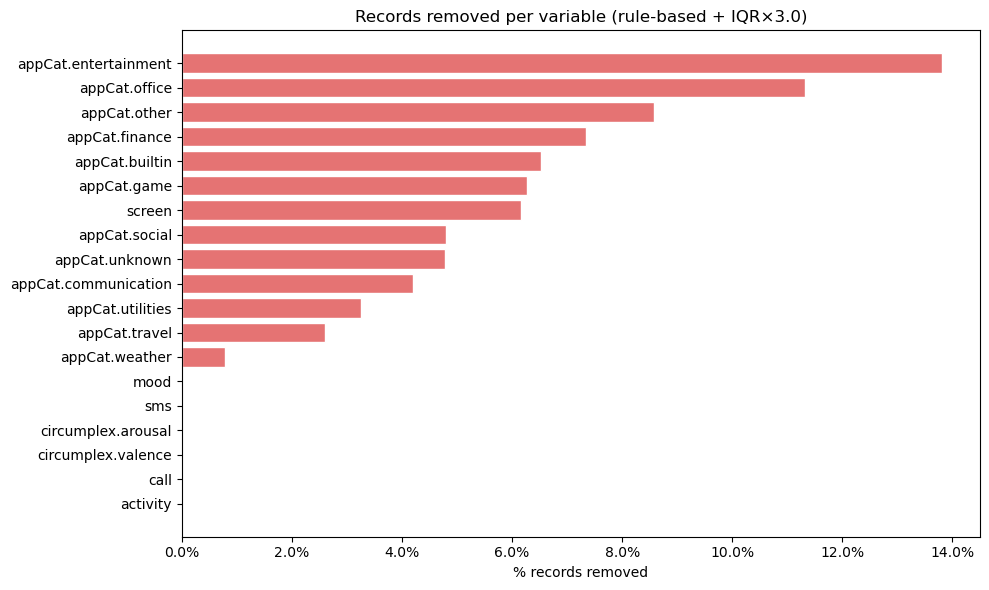

In [19]:
plot_df = (
    ba_report["pct_removed"]
    .sort_values(ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["variable"], plot_df["pct_removed"],
        color="#e57373", edgecolor="white")
ax.set_xlabel("% records removed")
ax.set_title(f"Records removed per variable (rule-based + IQR×{IQR_MULTIPLIER})")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig("../figures/outlier_removal_pct.png", dpi=150)
plt.show()

#### 7. Consolidated removal summary

In [20]:
total_raw     = len(df)
total_removed = total_raw - len(df_clean)

print("=" * 52)
print("CONSOLIDATED REMOVAL SUMMARY")
print("=" * 52)
print(f"  Raw records                       : {total_raw:,}")
print(f"  Removed (rule-based)              : {impossible_mask.sum():,}")
print(f"  Removed (IQR statistical)         : {extreme_mask.sum():,}")
print(f"  Total removed                     : {total_removed:,}  "
      f"({total_removed/total_raw*100:.2f}%)")
print(f"  Clean records                     : {len(df_clean):,}")
print(f"  Patients affected (any removal)   : "
      f"{df[~df.index.isin(df_clean.index)][ID_COL].nunique()}")
print("=" * 52)

CONSOLIDATED REMOVAL SUMMARY
  Raw records                       : 376,912
  Removed (rule-based)              : 4
  Removed (IQR statistical)         : 21,316
  Total removed                     : 21,320  (5.66%)
  Clean records                     : 355,592
  Patients affected (any removal)   : 27


#### 8. Export

In [21]:
rule_report.to_csv("../outputs/outlier_rule_based.csv")
stat_report.to_csv("../outputs/outlier_statistical.csv")
ba_report.to_csv("../outputs/outlier_before_after.csv")
df_clean.to_csv("../outputs/data_cleaned.csv", index=False)
print("Saved outlier reports and data_cleaned.csv")

Saved outlier reports and data_cleaned.csv


#### Why this matters


#### Notes


**Why three passes, not one**. Rule-based removal comes first because those values are not statistically extreme - they are logically impossible. A mood of 11 or a negative screen duration does not belong in any distribution. We remove those unconditionally before computing any statistics, so the IQR fences in pass 2 are not distorted by impossible values anchoring the tails.


**Why `SKIP_IQR` for mood, arousal, valence, activity, call, sms**. These variables have hard domain bounds already enforced in pass 1. Applying IQR on top would risk removing valid boundary values; for example, a mood of 1 or 10 is rare but completely valid. The domain rule is the correct and sufficient constraint for scale-bounded variables.


#### Additional Analysis


**Mean reductions are large and worth reporting explicitly.** The most affected:
- `appCat.entertainment`: 82.4% mean drop (37.58 → 6.61) from removing 13.8% of records
- `appCat.office`: 79.2% drop (22.58 → 4.69) from 11.3% removal  
- `appCat.builtin`: 65.9% drop (18.54 → 6.32); driven heavily by the single -82,798 record identified in b_02


**`data_cleaned.csv` contains a `date` column** that was not in the original raw data, it was added during b_04/b_05 processing. This is fine for the pipeline but document it in `task_notes.md` so teammates loading the file know the schema differs from the raw dataset.

**`appCat.game` IQR fence_lo is -314.** Since all game values are positive, the statistical method only removes from the top. This is correct behaviour, but worth one line in the notes explaining that for right-skewed duration variables the lower fence is irrelevant by construction.
